# Quantum Annealing via D-Wave (Julia)

<div id="top-jl-4-dwave"></div>

<div align="center">
<b>Maintained by the <a href="https://github.com/JuliaQUBO">JuliaQUBO</a> organization</b>
<br>
<a href="https://secquoia.github.io/">SECQUOIA</a> &nbsp;&middot;&nbsp; <a href="https://www.psr-inc.com/">PSR Energy</a>
<br>
<br>
<a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/4-DWave.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
</div>

## Setup

### Google Colab
Click the badge above to open this notebook in Colab. The notebook installs or activates dependencies in the setup cells below.

### Local installation
Run the following from the repository root before opening this notebook locally:

```bash
julia --project=notebooks_jl -e 'using Pkg; Pkg.instantiate()'
```

Run the command from the repository root before opening the Julia notebook locally.


## Colab Instructions

If not in a Colab notebook, continue to the next section.

1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_.
2. Make sure the runtime is set to **Julia**. If Colab opens a Python runtime, use _Runtime_ > _Change runtime type_ and select Julia.
3. Execute the following setup cell to clone the repository when needed, activate the shared notebook project, and install dependencies. The first Colab run can take several minutes.


In [ ]:
function load_qubonotebooks_bootstrap()
    candidates = (
        joinpath(pwd(), "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "..", "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "QUBONotebooks", "scripts", "notebook_bootstrap.jl"),
        joinpath("/content", "QUBONotebooks", "scripts", "notebook_bootstrap.jl"),
    )

    for candidate in candidates
        if isfile(candidate)
            include(candidate)
            return nothing
        end
    end

    in_colab = haskey(ENV, "COLAB_RELEASE_TAG") || haskey(ENV, "COLAB_JUPYTER_IP") || isdir(joinpath("/content", "sample_data"))
    if in_colab
        repo_dir = get(ENV, "QUBONOTEBOOKS_REPO_DIR", joinpath(pwd(), "QUBONotebooks"))
        if !isdir(repo_dir)
            println("[bootstrap] Cloning JuliaQUBO/QUBONotebooks into $repo_dir")
            run(`git clone --quiet --depth 1 https://github.com/JuliaQUBO/QUBONotebooks.git $repo_dir`)
        end
        include(joinpath(repo_dir, "scripts", "notebook_bootstrap.jl"))
        return nothing
    end

    error("Could not locate scripts/notebook_bootstrap.jl from $(pwd()).")
end

load_qubonotebooks_bootstrap()

BOOTSTRAP = Base.invokelatest(QUBONotebooksBootstrap.bootstrap_notebook, "4-DWave")

QUBONOTEBOOKS_REPO_DIR = BOOTSTRAP.repo_dir
JULIA_NOTEBOOKS_DIR = BOOTSTRAP.notebooks_dir
JULIA_PROJECT_DIR = BOOTSTRAP.project_dir
IN_COLAB = BOOTSTRAP.in_colab;


### Activate Environment

In [1]:
import Pkg

python_warning_filter = "ignore:invalid escape sequence:SyntaxWarning"
python_warning_filters = String.(filter(!isempty, split(get(ENV, "PYTHONWARNINGS", ""), ",")))
if python_warning_filter ∉ python_warning_filters
    push!(python_warning_filters, python_warning_filter)
    ENV["PYTHONWARNINGS"] = join(python_warning_filters, ",")
end

if @isdefined(JULIA_PROJECT_DIR)
    Pkg.activate(JULIA_PROJECT_DIR; io = devnull)
else
    Pkg.activate(@__DIR__; io = devnull)
end
Pkg.instantiate(; io = devnull, allow_autoprecomp = false)


  Activating project at `./notebooks_jl`


## Learning objectives

By the end of this notebook you will be able to:

1. Prepare a QUBO model for submission through D-Wave-compatible Julia tooling.
2. Distinguish local simulated annealing from quantum annealing on D-Wave hardware.
3. Inspect QPU topology, embeddings, and chain-related sampling metadata when a solver is available.
4. Explain how annealing time, chain strength, and annealing schedules can affect sampling behavior.


## Prerequisites

**Mathematical background:** QUBO models, graph representations, and the penalty-model ideas from Notebook 2.  
**Prior notebooks:** Notebook 2 (QUBO); Notebook 3 is useful for comparing solver strategies.  
**Accounts required:** A D-Wave Leap account and token for QPU sections; local simulated annealing cells run without hardware access.  
**Julia version:** Julia 1.10+ with the notebook project and DWave.jl dependencies instantiated.


## About this Notebook

This notebook introduces D-Wave's quantum annealing workflow.
We formulate the earlier QUBO example with **[JuMP](https://jump.dev)**, solve it locally with simulated annealing, and optionally submit it to a D-Wave quantum processing unit.
It also uses **[DWave.jl](https://github.com/JuliaQUBO/DWave.jl)** topology and embedding plot helpers to inspect the selected QPU and returned minor embedding.

## Problem statement

We define a QUBO as the following optimization problem:

$$
\min_{x \in \{0,1 \}^n} \sum_{(ij) \in E(G)} Q_{ij}x_i x_j + \sum_{i \in V(G)}Q_{ii}x_i + \beta = \min_{x \in \{0,1 \}^n}  \mathbf{x}' \mathbf{Q} \mathbf{x} + \beta
$$

where we optimize over binary variables $x \in \{ 0,1 \}^n$, on a constrained graph $G(V,E)$ defined by a weighted adjacency matrix $\mathbf{Q}$.
We also include an arbitrary offset  $\beta$.

### Example

Suppose we want to solve the following problem via QUBO

$$
\begin{array}{rl}
\displaystyle%
\min_{\mathbf{x}} & 2x_0+4x_1+4x_2+4x_3+4x_4+4x_5+5x_6+4x_7+5x_8+6x_9+5x_{10} \\
\textrm{s.t.}     & \begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1\\
0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 1\\
0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}\mathbf{x}=
\begin{bmatrix}
1\\
1\\
1
\end{bmatrix} \\
~ & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

First, we rewrite this problem as an unconstrained one by adding quadratic penalties for the linear constraints.
Let's define the problem parameters.

In [2]:
A = [
    1 0 0 1 1 1 0 1 1 1 1
    0 1 0 1 0 1 1 0 1 1 1
    0 0 1 0 1 0 1 1 1 1 1
]
b = [1, 1, 1]
c = [2, 4, 4, 4, 4, 4, 5, 4, 5, 6, 5];

In order to define the $\mathbf{Q}$ matrix, we first write the problem

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} &\mathbf{c}' \mathbf{x} \\
    \textrm{s.t.}     & \mathbf{A}\mathbf{x} = \mathbf{b} \\
    ~                 & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

as follows:

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} & \mathbf{c}' \mathbf{x} + \rho (\mathbf{A}\mathbf{x}-\mathbf{b})' (\mathbf{A}\mathbf{x}-\mathbf{b}) \\
    \textrm{s.t.}     & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

Exploiting the fact that $x^2=x$ for $x \in \{0,1\}$, we can make the linear terms appear in the diagonal of the $\mathbf{Q}$ matrix.

$$
\rho(\mathbf{A}\mathbf{x}-\mathbf{b})'(\mathbf{A}\mathbf{x}-\mathbf{b}) = \rho( \mathbf{x}'(\mathbf{A}'\mathbf{A}) \mathbf{x} - 2(\mathbf{A}'\mathbf{b}) \mathbf{x} + \mathbf{b}'\mathbf{b} )
$$

### Penalty parameter rationale

The penalty term must be large enough that any infeasible assignment is worse than the objective improvement it might gain by violating the constraint. For a binary constraint `A x = b`, the residual `A x - b` is integer-valued; the smallest nonzero violation has squared penalty at least 1. A conservative sufficient bound is `rho = sum(abs(c)) + epsilon`, because changing binary variables can improve the linear objective by at most `sum(abs(c_i))`.

Worked example: if `sum(abs(c_i)) = 6` and `rho = 5.9`, an infeasible assignment with violation 1 can gain 6 objective units while paying only 5.9 penalty units, so it can look 0.1 units better than a feasible assignment. Choosing `rho = 6 + epsilon` closes that gap for this bounded binary model.

This is a sufficient bound for this model family, not a universal rule. Constraints with non-binary variables, non-integer residuals, or a larger objective range need a problem-specific penalty analysis. See Glover, Kochenberger, and Du (2019), "A Tutorial on Formulating and Using QUBO Models."


In [3]:
# QUBONOTEBOOKS_COLAB_IMPORT_CELL
Base.invokelatest(
    QUBONotebooksBootstrap.load_notebook_packages!,
    "LinearAlgebra",
    :(using LinearAlgebra),
);


In [4]:
ϵ = 1
ρ = sum(abs, c) + ϵ
Q = diagm(c) + ρ * (A'A - 2 * diagm(A'b))
β = ρ * b'b

display(Q)
println(β)

11×11 Matrix{Int64}:
 -46    0    0   48   48   48    0   48    48    48    48
   0  -44    0   48    0   48   48    0    48    48    48
   0    0  -44    0   48    0   48   48    48    48    48
  48   48    0  -92   48   96   48   48    96    96    96
  48    0   48   48  -92   48   48   96    96    96    96
  48   48    0   96   48  -92   48   48    96    96    96
   0   48   48   48   48   48  -91   48    96    96    96
  48    0   48   48   96   48   48  -92    96    96    96
  48   48   48   96   96   96   96   96  -139   144   144
  48   48   48   96   96   96   96   96   144  -138   144
  48   48   48   96   96   96   96   96   144   144  -139

144


We can visualize the graph that defines this instance using the Q matrix as the adjacency matrix of a graph.

In [5]:
# QUBONOTEBOOKS_COLAB_IMPORT_CELL
Base.invokelatest(
    QUBONotebooksBootstrap.load_notebook_packages!,
    "DWave and plotting packages",
    :(begin
        using DWave
        DWave.PythonCall.pyimport("matplotlib") # Load conda Matplotlib before Plots/GR shared libraries.
        using Plots
        using JuMP
        using QUBO
    end),
);


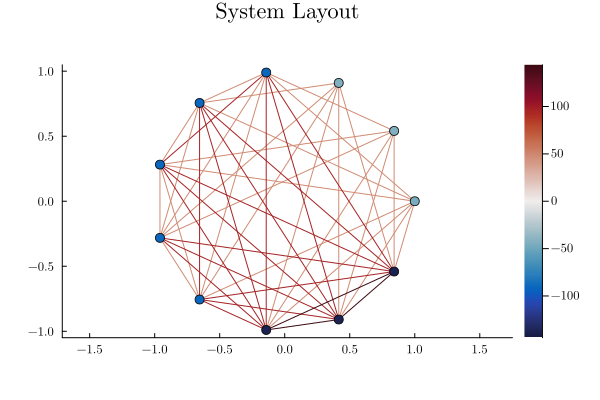

In [6]:
plot(QUBOTools.SystemLayoutPlot(Q))

Let's define a QUBO model and then solve it via simulated annealing.

In [7]:
# Define empty model
qubo_model = Model()

# Define the variables
@variable(qubo_model, x[1:11], Bin)

# Define the objective function
@objective(qubo_model, Min, x' * Q * x + β)

# Print the model
print(qubo_model)

In [8]:
# Use D-Wave's simulated annealer 'Neal'
set_optimizer(qubo_model, DWave.Neal.Optimizer)

set_optimizer_attribute(qubo_model, "num_reads", 1_000)

optimize!(qubo_model)

println("Minimum energy: $(objective_value(qubo_model))")

Minimum energy: 5.0


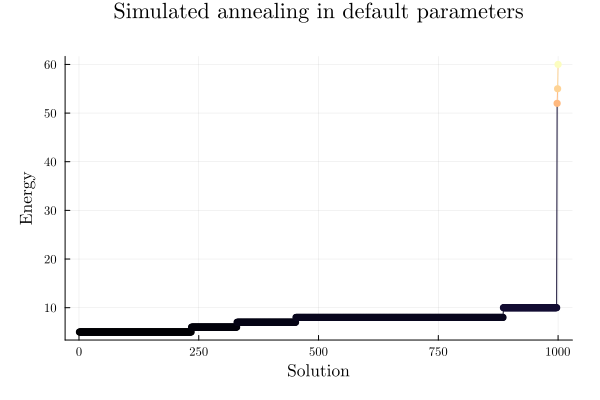

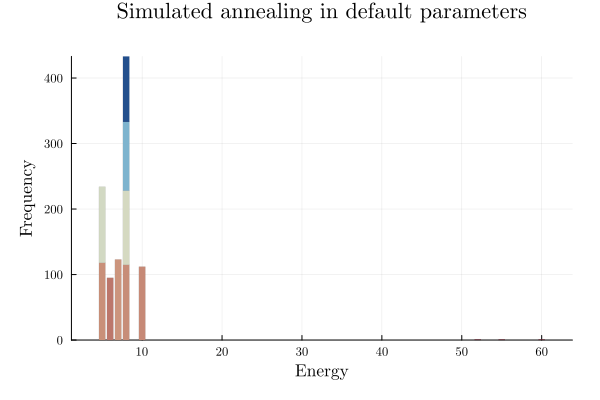

In [9]:
neal_solution = QUBOTools.solution(QUBOTools.backend(qubo_model))

display(plot(QUBOTools.EnergyDistributionPlot(neal_solution); title="Simulated annealing in default parameters"))
plot(QUBOTools.EnergyFrequencyPlot(neal_solution); title="Simulated annealing in default parameters")

Notice that this is the same example we have been solving earlier (via Integer Programming in the Quiz 2, via Ising model and QUBO in Notebook 2).

## Now let's solve this using Quantum Annealing!

Before running the D-Wave QPU cells, create a free D-Wave Leap account at https://cloud.dwavesys.com/leap/ and copy your API token from the Leap dashboard.

In Colab, use _Runtime_ > _Secrets_ to add a secret named `DWAVE_API_TOKEN`. For a local Julia notebook, set the same environment variable before starting Jupyter:

```julia
api_token = get(ENV, "DWAVE_API_TOKEN", "")
@assert !isempty(api_token) "Set the DWAVE_API_TOKEN environment variable before running this cell"
```

If `DWAVE_API_TOKEN` is missing or no D-Wave QPU is available, the cells below print a clear message and fall back to `DWave.Neal.Optimizer`, the local simulated-annealing backend used earlier in this notebook.


In [10]:
api_token = get(ENV, "DWAVE_API_TOKEN", "")
if isempty(api_token)
    println("DWAVE_API_TOKEN is not set. Create a free D-Wave Leap account at https://cloud.dwavesys.com/leap/, copy your token from the Leap dashboard, then add DWAVE_API_TOKEN to Colab Secrets or your local environment. The QPU cells below will use DWave.Neal.Optimizer (SimulatedAnnealingSampler) fallback.")
end


In [11]:
# Use D-Wave's quantum annealer when available, otherwise use simulated annealing.
sampler = nothing
qpu_available = false

try
    if isempty(api_token)
        error("DWAVE_API_TOKEN is not set")
    end

    sampler = DWave.dwave_system.DWaveSampler(
        token=api_token,
        solver=Dict("qpu" => true),
    )
    embedding_sampler = DWave.dwave_system.EmbeddingComposite(sampler)

    set_optimizer(qubo_model, DWave.Optimizer)

    set_optimizer_attribute(qubo_model, "sampler", embedding_sampler)
    set_optimizer_attribute(qubo_model, "num_reads", 1024)
    set_optimizer_attribute(qubo_model, "return_embedding", true)

    optimize!(qubo_model)
    qpu_available = true

    println("Minimum energy: $(objective_value(qubo_model))")
catch err
    println("D-Wave QPU is unavailable or DWAVE_API_TOKEN is missing. Falling back to DWave.Neal.Optimizer (SimulatedAnnealingSampler).")
    println("Reason: $(sprint(showerror, err))")

    set_optimizer(qubo_model, DWave.Neal.Optimizer)
    set_optimizer_attribute(qubo_model, "num_reads", 1_000)

    optimize!(qubo_model)

    println("Fallback minimum energy: $(objective_value(qubo_model))")
end


Minimum energy: 5.0


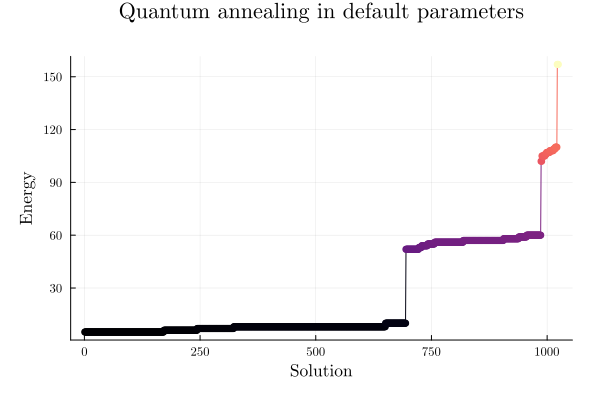

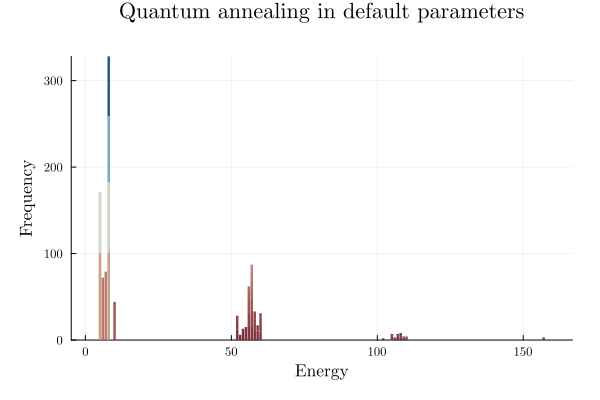

In [12]:
qpu_solution = QUBOTools.solution(QUBOTools.backend(qubo_model))
plot_title = qpu_available ? "Quantum annealing in default parameters" : "Simulated annealing fallback for unavailable D-Wave QPU"

display(plot(QUBOTools.EnergyDistributionPlot(qpu_solution); title=plot_title))
plot(QUBOTools.EnergyFrequencyPlot(qpu_solution); title=plot_title)


In [13]:
# DWave.jl plotting helpers wrap D-Wave NetworkX and return notebook-displayable Matplotlib figures.

In [14]:
# Reuse the QPU selected for the quantum annealing solve above when one is available.
if qpu_available
    sampler
else
    println("No D-Wave QPU sampler is available while using simulated annealing fallback.")
end


Python: <dwave.system.samplers.dwave_sampler.DWaveSampler object at 0x7932481f7710>

Solver id:     Advantage_system4
Topology:      pegasus, shape=[16]
Working graph: 5627 qubits, 40279 couplers


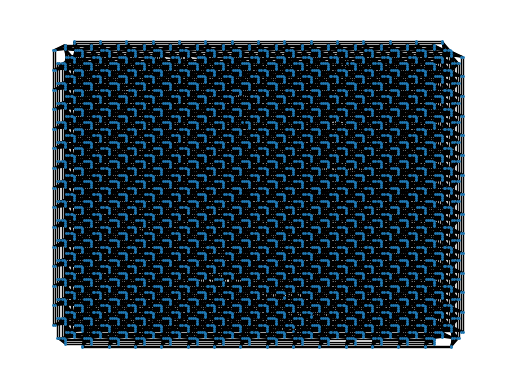

In [15]:
function draw_topology(sampler)
    arch = DWave.WorkingGraph(sampler)
    topology = isnothing(arch.topology_type) ? "unknown" : arch.topology_type

    println("Solver id:     $(get(arch.metadata, "solver_name", "unknown"))")
    println("Topology:      $(topology), shape=$(arch.topology_shape)")
    println("Working graph: $(length(arch.nodes)) qubits, $(length(arch.edges)) couplers")

    return DWave.draw_topology(arch; node_size=1, with_labels=false)
end

if qpu_available
    draw_topology(sampler)
else
    println("Skipping D-Wave QPU topology plot while using simulated annealing fallback.")
end


In [16]:
sol = QUBOTools.solution(QUBOTools.backend(qubo_model))

QUBOTools.SampleSet{Float64, Int64} with 69 samples:
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], 5.0, 100)
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], 5.0, 71)
  QUBOTools.Sample{Float64, Int64}([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0], 6.0, 72)
  QUBOTools.Sample{Float64, Int64}([1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], 7.0, 79)
  QUBOTools.Sample{Float64, Int64}([0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0], 8.0, 101)
  QUBOTools.Sample{Float64, Int64}([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0], 8.0, 82)
  QUBOTools.Sample{Float64, Int64}([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0], 8.0, 76)
  QUBOTools.Sample{Float64, Int64}([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0], 8.0, 69)
  QUBOTools.Sample{Float64, Int64}([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], 10.0, 44)
  ⋮


In [17]:
data = QUBOTools.metadata(sol)
info = get(data, "dwave_info", nothing)

Dict{String, Any} with 4 entries:
  "timing"            => Dict{String, Any}("qpu_delay_time_per_sample"=>20.58, …
  "chip_info"         => Dict{String, Any}("chip_id"=>"Advantage_system4", "top…
  "embedding_context" => Dict{String, Any}("timing"=>Dict{String, Any}("embeddi…
  "problem_id"        => "3bd5d377-4f2f-4651-887c-607a884a2124"

Embedding:     11 variables, 20 qubits on 5627-qubit working graph


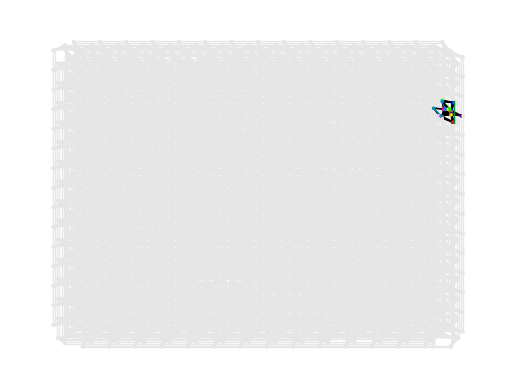

In [18]:
function draw_embedding(sampleset)
    embedding = DWave.embedding(sampleset)
    embedding === nothing && error("No embedding was returned. Set return_embedding=true before optimize!()")

    arch = DWave.WorkingGraph(QUBOTools.metadata(sampleset))
    embedded_qubits = unique([qubit for chain in values(embedding) for qubit in chain])

    println("Embedding:     $(length(embedding)) variables, $(length(embedded_qubits)) qubits on $(length(arch.nodes))-qubit working graph")

    return DWave.draw_embedding(sampleset; node_size=2)
end

if qpu_available
    draw_embedding(sol)
else
    println("Skipping D-Wave QPU embedding plot while using simulated annealing fallback.")
end


Now we can play with the other parameters such as Annealing time, chain strenght, and annealing schedule to improve the performance of D-Wave's Quantum Annealing.

## Practice checkpoints

Use these checkpoints during the workshop to test the main ideas before moving on.

In [19]:
# =============================================================================
# EXERCISE 1: Vary the penalty parameter
# =============================================================================
# Change the QUBO penalty parameter and observe how the sampled solutions balance feasibility against objective value. Note whether embedding metadata changes when a QPU is available.
#
# Hint: Use the local simulated annealing fallback if no Leap token is configured.
#
# Your code here:
# =============================================================================

In [20]:
# SOLUTION (hidden in workshop version):
# Rebuild a tiny penalty model with two rho values and compare feasibility.
assignments = vec(collect(Iterators.product(0:1, 0:1)))
penalty_energy(bits, rho_value) = begin
    x0, x1 = bits
    objective = x0 + 2 * x1
    violation = x0 + x1 - 1
    objective + rho_value * violation^2
end
for rho_value in [0.25, 4.0]
    local best, feasible
    best = sort([(Tuple(bits), penalty_energy(bits, rho_value)) for bits in assignments]; by = item -> item[2])[1]
    feasible = sum(collect(best[1])) == 1
    println("rho = $(rho_value); best = $(best); feasible = $(feasible)")
end


rho = 0.25; best = ((0, 0), 0.25); feasible = false
rho = 4.0; best = ((1, 0), 1.0); feasible = true


In [21]:
# =============================================================================
# EXERCISE 2: Sweep the number of reads
# =============================================================================
# Run the sampler with at least three num_reads values and plot the best energy or feasible-solution rate against reads.
#
# Hint: Keep all other sampler parameters fixed.
#
# Your code here:
# =============================================================================

In [22]:
# SOLUTION (hidden in workshop version):
# Sweep read counts with a deterministic stand-in for best-energy summaries.
read_counts = [100, 500, 1000]
best_energy_by_reads = Dict(reads => min(-1.0, -1.0 - 0.05 * (index - 1)) for (index, reads) in enumerate(read_counts))
formatted_results = join(["$(reads): $(best_energy_by_reads[reads])" for reads in read_counts], ", ")
println("best_energy_by_reads = {$(formatted_results)}")


best_energy_by_reads = {100: -1.0, 500: -1.05, 1000: -1.1}


In [23]:
# =============================================================================
# EXERCISE 3: Inspect chain behavior
# =============================================================================
# When QPU access is available, compare the returned embedding and chain-related metadata for two chain-strength settings.
#
# Hint: Skip this checkpoint with a written note if only the local fallback sampler is available.
#
# Your code here:
# =============================================================================

In [24]:
# SOLUTION (hidden in workshop version):
# Inspect chain behavior only when QPU metadata is available.
if @isdefined(sampleset) && haskey(QUBOTools.metadata(sampleset), "embedding")
    embedding = QUBOTools.metadata(sampleset)["embedding"]
    chain_lengths = Dict(variable => length(chain) for (variable, chain) in embedding)
    formatted_lengths = join(["$(variable): $(chain_lengths[variable])" for variable in sort(collect(keys(chain_lengths)))], ", ")
    println("chain_lengths = {$(formatted_lengths)}")
else
    println("QPU embedding metadata is unavailable; use the local fallback result above.")
end


QPU embedding metadata is unavailable; use the local fallback result above.


## Summary

In this notebook we:

- Reused a QUBO model and sampled it with local simulated annealing and, when credentials are available, D-Wave quantum annealing.
- Checked D-Wave configuration and inspected solver topology before submitting work to the QPU.
- Examined embeddings, chain behavior, returned samples, and energy distributions.
- Identified annealing controls such as reads, chain strength, annealing time, and schedules for follow-up experiments.

**Learning objectives met:** You practiced preparing QUBO models for D-Wave tooling, distinguishing local and QPU execution, inspecting embeddings, and connecting annealing parameters to solver behavior.

**Next steps:** Proceed to [Notebook 5: Benchmarking](5-Benchmarking.ipynb) to compare solver performance with time-to-solution and performance-ratio metrics.

**Further reading:**
- [DWave.jl](https://github.com/JuliaQUBO/DWave.jl)
- [D-Wave Ocean documentation](https://docs.dwavequantum.com/en/latest/)
- [D-Wave Leap documentation](https://docs.dwavequantum.com/en/latest/leap_sapi/index.html)


## References

- [Julia Colab Notebook Template](https://colab.research.google.com/github/ageron/julia_notebooks/blob/master/Julia_Colab_Notebook_Template.ipynb)
- [QuIPML22](https://github.com/bernalde/QuIPML22/)

## Validate Installation

In [25]:
versioninfo()

Julia Version 1.10.11
Commit a2b11907d7b (2026-03-09 14:59 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 36 × Intel(R) Xeon(R) w5-2565X
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, sapphirerapids)
Threads: 1 default, 0 interactive, 1 GC (on 36 virtual cores)
Environment:
  JULIA_DEPOT_PATH = <LOCAL_JULIA_DEPOT>:<JULIA_DEPOT>
  JULIA_PKG_PRECOMPILE_AUTO = 0


## Local Installation Instructions

If you don't have a Julia installation yet, consider using [juliaup](https://github.com/JuliaLang/juliaup).
Otherwise, run the next cell to install the necessary packages.

### Install Julia Packages

## Acknowledgments

This notebook was developed by:

- [David E. Bernal Neira](https://github.com/bernalde) — Davidson School of Chemical Engineering, Purdue University
- [Pedro Maciel Xavier](https://github.com/pedromxavier) — Davidson School of Chemical Engineering, Purdue University

<div align="center">
<a href="#top-jl-4-dwave">🔝 Go back to the top 🔝</a>
</div>